In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.integrate import solve_ivp
import os
import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
import math
from sklearn.model_selection import train_test_split
from functools import reduce
from functools import partial
import operator
from timeit import default_timer
from matplotlib.ticker import FormatStrFormatter
import deepxde as dde
from scipy import linalg
from scipy.interpolate import interp1d
import datetime
import time

Using backend: pytorch
Other supported backends: tensorflow.compat.v1, tensorflow, jax, paddle.
paddle supports more examples now and is recommended.
D:\Anaconda\envs\DeepONetEnv2\lib\site-packages\torch\__init__.py:747: UserWarning: torch.set_default_tensor_type() is deprecated as of PyTorch 2.1, please use torch.set_default_dtype() and torch.set_default_device() as alternatives. (Triggered internally at C:\cb\pytorch_1000000000000\work\torch\csrc\tensor\python_tensor.cpp:433.)
  _C._set_default_tensor_type(t)


In [2]:
# Create img directory if it doesn't exist
os.makedirs('img', exist_ok=True)
# Create Model directory if it doesn't exist
os.makedirs('Model', exist_ok=True)

In [3]:
# ============================================================================
# 1. FUNCTION DEFINITIONS
# ============================================================================

def kernel_estimator(Sigma11, Sigma12, Sigma21, Sigma22, Q, A, B, C, C_0, dx, Nx, Lambda, mu):
    """Compute kernel functions"""
    K1 = np.zeros((Nx, Nx))
    K2 = np.zeros((Nx, Nx))
    K3 = np.zeros((Nx, Nx))
    N = np.zeros((Nx, Nx))
    gamma = np.zeros((Nx, 2))
    
    for i in range(Nx):
        K1[i, i] = -Sigma21[0] / (Lambda[0, 0] + mu)
        K2[i, i] = -Sigma21[1] / (Lambda[1, 1] + mu)
        K3[i, i] = -Sigma21[2] / (Lambda[2, 2] + mu)
    
    gamma[1, :] = gamma[0, :] + dx/mu * (gamma[0, :] @ A - Sigma22 * gamma[0, :] - 
                 (K1[0, 0]*Lambda[0, 0]*C_0[0, :] + K2[0, 0]*Lambda[1, 1]*C_0[1, :] + 
                  K3[0, 0]*Lambda[2, 2]*C_0[2, :]))
    
    N[1, 0] = 1/mu * (gamma[1, :] @ B + Q[0, 0]*K1[1, 0]*Lambda[0, 0] + 
                      Q[1, 0]*K2[1, 0]*Lambda[1, 1] + Q[2, 0]*K3[1, 0]*Lambda[2, 2])
    
    K1[1, 0] = K1[1, 1]
    K2[1, 0] = K2[1, 1]
    K3[1, 0] = K3[1, 1]
    N[1, 1] = N[1, 0]
    
    for i in range(1, Nx-1):
        for j in range(i):
            K1[i+1, j] = (K1[i, j] + Lambda[0, 0]/mu * dx/dx * (K1[i, j+1] - K1[i, j]) + 
                         dx/mu * ((Sigma11[0, 0] - Sigma22) * K1[i, j] + Sigma21[0] * N[i, j]))
            K2[i+1, j] = (K2[i, j] + Lambda[1, 1]/mu * dx/dx * (K2[i, j+1] - K2[i, j]) + 
                         dx/mu * ((Sigma11[1, 1] - Sigma22) * K2[i, j] + Sigma21[1] * N[i, j]))
            K3[i+1, j] = (K3[i, j] + Lambda[2, 2]/mu * dx/dx * (K3[i, j+1] - K3[i, j]) + 
                         dx/mu * ((Sigma11[2, 2] - Sigma22) * K3[i, j] + Sigma21[2] * N[i, j]))
            N[i+1, j+1] = (N[i, j+1] - dx/dx * (N[i, j+1] - N[i, j]) + 
                          dx/mu * (Sigma12[0, 0]*K1[i, j+1] + Sigma12[1, 0]*K2[i, j+1] + 
                                  Sigma12[2, 0]*K3[i, j+1]))
        
        N[i+1, i+1] = N[i+1, i]
        gamma[i+1, :] = (gamma[i, :] + dx/mu * (gamma[i, :] @ A - Sigma22 * gamma[i, :] - 
                       (K1[i, 0]*Lambda[0, 0]*C_0[0, :] + K2[i, 0]*Lambda[1, 1]*C_0[1, :] + 
                        K3[i, 0]*Lambda[2, 2]*C_0[2, :])))
        
        N[i+1, 0] = 1/mu * (gamma[i+1, :] @ B + Q[0, 0]*K1[i+1, 0]*Lambda[0, 0] + 
                           Q[1, 0]*K2[i+1, 0]*Lambda[1, 1] + Q[2, 0]*K3[i+1, 0]*Lambda[2, 2])
        
        if i > 0:
            K1[i+1, i] = (K1[i+1, i-1] + K1[i+1, i+1]) / 2
            K2[i+1, i] = (K2[i+1, i-1] + K2[i+1, i+1]) / 2
            K3[i+1, i] = (K3[i+1, i-1] + K3[i+1, i+1]) / 2
    
    return K1, K2, K3, N, gamma

def generate_tau(t_val, kappa, epsilon):
    """Generate transition rate matrix"""
    r = 5
    tau = np.zeros((r, r))
    
    for i in range(r):
        for j in range(r):
            if i == j:
                tau[i, j] = 0
            elif i in [0, 4]:  
                tau[i, j] = 2 * kappa
            elif i in [1, 2, 3] and j in [0, 4]:
                tau[i, j] = 0.1 * kappa
            elif i in [1, 2, 3] and j in [1, 2, 3] and i != j:
                freq = epsilon * (i + 5*j)
                tau[i, j] = kappa * (1 + 2 * np.cos(freq * t_val))**2
    
    return tau

def solve_kolmogorov(tau, t0, tf):
    """Solve Kolmogorov equation"""
    r = tau.shape[0]
    
    def dPdt(t_val, P_flat):
        P = P_flat.reshape(r, r)
        dP = tau @ P
        return dP.flatten()
    
    P0 = np.eye(r).flatten()
    sol = solve_ivp(dPdt, [t0, tf], P0, method='RK45', rtol=1e-8)
    P = sol.y[:, -1].reshape(r, r)
    
    P = np.maximum(P, 0)
    P = P / np.sum(P, axis=1, keepdims=True)
    
    return P

def solve_pde(params):
    """Main PDE solver"""
    # Extract parameters
    grid_params = params['grid']
    system_params = params['system']
    initial_conditions = params['initial']
    markov_params = params['markov']
    
    L = grid_params['L']
    T = grid_params['T']
    dx = grid_params['dx']
    dt = grid_params['dt']
    
    x = np.arange(0, L + dx, dx)
    t = np.arange(0, T + dt, dt)
    Nx = len(x)
    Nt = len(t)
    
    r = 5
    w1 = np.zeros((Nx, Nt))
    w2 = np.zeros((Nx, Nt))
    w3 = np.zeros((Nx, Nt))
    z = np.zeros((Nx, Nt))
    X = np.zeros((2, Nt))
    
    w1[:, 0] = np.sin(2 * np.pi * x)
    w2[:, 0] = np.sin(2 * np.pi * x)
    w3[:, 0] = np.sin(2 * np.pi * x)
    z[:, 0] = x.copy()
    X[:, 0] = np.array([1, -1])
    
    prob_matrix = np.zeros((Nt, r))
    initial_probs = np.array([0, 1/3, 1/3, 1/3, 0])
    prob_matrix[0, :] = initial_probs
    
    U = np.zeros(Nt)
    
    kappa = markov_params['kappa']
    epsilon = markov_params['epsilon']
    mu_values = markov_params['mu_values']
    
    mode_params = []
    
    Lambda = system_params['Lambda']
    Sigma11 = system_params['Sigma11']
    Sigma12 = system_params['Sigma12']
    Sigma21 = system_params['Sigma21']
    Sigma22 = system_params['Sigma22']
    Q = system_params['Q']
    A = system_params['A']
    B = system_params['B']
    C = system_params['C']
    C_0 = system_params['C_0']
    mu = system_params['mu']
    
    K1_r, K2_r, K3_r, N_r, gamma_r = kernel_estimator(
        Sigma11, Sigma12, Sigma21, Sigma22, 
        Q, A, B, C, C_0, dx, Nx, Lambda, mu)
    
    for k in range(r):
        param = {
            'Lambda': Lambda.copy(),
            'Sigma11': Sigma11.copy(),
            'Sigma12': Sigma12.copy(),
            'Sigma21': Sigma21.copy(),
            'Sigma22': Sigma22,
            'mu': mu_values[k],
            'A': A.copy(),
            'B': B.copy(),
            'K': system_params['K'].copy(),
            'C': C.copy(),
            'Q': Q.copy(),
            'R': system_params['R'].copy(),
            'K1_r': K1_r.copy(),
            'K2_r': K2_r.copy(),
            'K3_r': K3_r.copy(),
            'C_0': C_0.copy(),
            'N_r': N_r.copy(),
            'gamma_r': gamma_r.copy()
        }
        mode_params.append(param)
    
    current_mode = np.random.choice(r, p=initial_probs)
    
    for j in range(1, Nt):
        tau_current = generate_tau(t[j], kappa, epsilon)
        P = solve_kolmogorov(tau_current, t[j-1], t[j])
        prob_matrix[j, :] = prob_matrix[j-1, :] @ P
        prob_matrix[j, :] = np.maximum(prob_matrix[j, :], 0)
        prob_matrix[j, :] = prob_matrix[j, :] / np.sum(prob_matrix[j, :])
        
        current_mode = np.random.choice(r, p=prob_matrix[j, :])
        p = mode_params[current_mode]
        
        gamma = p['gamma_r']
        Sigma21_mode = p['Sigma21']
        Sigma11_mode = p['Sigma11']
        Sigma12_mode = p['Sigma12']
        Sigma22_mode = p['Sigma22']
        Lambda_mode = p['Lambda']
        mu_mode = p['mu']
        R = p['R']
        Q_mode = p['Q']
        K1 = p['K1_r']
        K2 = p['K2_r']
        K3 = p['K3_r']
        N = p['N_r']
        A_mode = p['A']
        B_mode = p['B']
        C_mode = p['C']
        
        integral_term = 0
        for m in range(Nx):
            integral_term += (K1[Nx-1, m]*w1[m, j-1] + 
                            K2[Nx-1, m]*w2[m, j-1] + 
                            K3[Nx-1, m]*w3[m, j-1] + 
                            N[Nx-1, m]*z[m, j-1]) * dx
        
        U[j] = (integral_term - (R[0]*w1[0, j-1] + R[1]*w2[0, j-1] + R[2]*w3[0, j-1]) + 
               gamma[Nx-1, :] @ X[:, j-1])
        
        z[0, j] = (z[0, j-1] + mu_mode*dt/dx*(z[1, j-1] - z[0, j-1]) + 
                  dt*(Sigma21_mode[0]*w1[0, j-1] + Sigma21_mode[1]*w2[0, j-1] + 
                      Sigma21_mode[2]*w3[0, j-1] + Sigma22_mode*z[0, j-1]))
        
        w1[0, j] = Q_mode[0, 0]*z[0, j-1] + C_mode[0, :] @ X[:, j-1]
        w2[0, j] = Q_mode[1, 0]*z[0, j-1] + C_mode[1, :] @ X[:, j-1]
        w3[0, j] = Q_mode[2, 0]*z[0, j-1] + C_mode[2, :] @ X[:, j-1]
        
        for i in range(1, Nx-1):
            w1[i, j] = (w1[i, j-1] - Lambda_mode[0, 0]*dt/dx*(w1[i, j-1] - w1[i-1, j-1]) + 
                       dt*(Sigma11_mode[0, 0]*w1[i, j-1] + Sigma12_mode[0, 0]*z[i, j-1]))
            w2[i, j] = (w2[i, j-1] - Lambda_mode[1, 1]*dt/dx*(w2[i, j-1] - w2[i-1, j-1]) + 
                       dt*(Sigma11_mode[1, 1]*w2[i, j-1] + Sigma12_mode[1, 0]*z[i, j-1]))
            w3[i, j] = (w3[i, j-1] - Lambda_mode[2, 2]*dt/dx*(w3[i, j-1] - w3[i-1, j-1]) + 
                       dt*(Sigma11_mode[2, 2]*w3[i, j-1] + Sigma12_mode[2, 0]*z[i, j-1]))
            z[i, j] = (z[i, j-1] + mu_mode*dt/dx*(z[i+1, j-1] - z[i, j-1]) + 
                      dt*(Sigma21_mode[0]*w1[i, j-1] + Sigma21_mode[1]*w2[i, j-1] + 
                          Sigma21_mode[2]*w3[i, j-1] + Sigma22_mode*z[i, j-1]))
        
        z[Nx-1, j] = R[0]*w1[0, j-1] + R[1]*w2[0, j-1] + R[2]*w3[0, j-1] + U[j]
        
        w1[Nx-1, j] = (w1[Nx-1, j-1] - Lambda_mode[0, 0]*dt/dx*(w1[Nx-1, j-1] - w1[Nx-2, j-1]) + 
                       dt*(Sigma11_mode[0, 0]*w1[Nx-1, j-1] + Sigma12_mode[0, 0]*z[Nx-1, j-1]))
        w2[Nx-1, j] = (w2[Nx-1, j-1] - Lambda_mode[1, 1]*dt/dx*(w2[Nx-1, j-1] - w2[Nx-2, j-1]) + 
                       dt*(Sigma11_mode[1, 1]*w2[Nx-1, j-1] + Sigma12_mode[1, 0]*z[Nx-1, j-1]))
        w3[Nx-1, j] = (w3[Nx-1, j-1] - Lambda_mode[2, 2]*dt/dx*(w3[Nx-1, j-1] - w3[Nx-2, j-1]) + 
                       dt*(Sigma11_mode[2, 2]*w3[Nx-1, j-1] + Sigma12_mode[2, 0]*z[Nx-1, j-1]))
        
        X[:, j] = X[:, j-1] + dt * (A_mode @ X[:, j-1] + B_mode.flatten() * z[0, j-1])
    
    return w1, w2, w3, z, X, U, prob_matrix, K1_r, K2_r, K3_r, N_r, gamma_r, mu_values, x, t

def solve_pde_NO(params,l_1):
    """Main PDE solver"""
    # Extract parameters
    grid_params = params['grid']
    system_params = params['system']
    initial_conditions = params['initial']
    markov_params = params['markov']
    
    L = grid_params['L']
    T = grid_params['T']
    dx = grid_params['dx']
    dt = grid_params['dt']
    
    x = np.arange(0, L + dx, dx)
    t = np.arange(0, T + dt, dt)
    Nx = len(x)
    Nt = len(t)
    
    r = 5
    w1 = np.zeros((Nx, Nt))
    w2 = np.zeros((Nx, Nt))
    w3 = np.zeros((Nx, Nt))
    z = np.zeros((Nx, Nt))
    X = np.zeros((2, Nt))
    
    w1[:, 0] = np.sin(2 * np.pi * x)
    w2[:, 0] = np.sin(2 * np.pi * x)
    w3[:, 0] = np.sin(2 * np.pi * x)
    z[:, 0] = x.copy()
    X[:, 0] = np.array([1, -1])
    
    prob_matrix = np.zeros((Nt, r))
    initial_probs = np.array([0, 1/3, 1/3, 1/3, 0])
    prob_matrix[0, :] = initial_probs
    
    U = np.zeros(Nt)
    
    kappa = markov_params['kappa']
    epsilon = markov_params['epsilon']
    mu_values = markov_params['mu_values']
    
    mode_params = []
    
    Lambda = system_params['Lambda']
    Sigma11 = system_params['Sigma11']
    Sigma12 = system_params['Sigma12']
    Sigma21 = system_params['Sigma21']
    Sigma22 = system_params['Sigma22']
    Q = system_params['Q']
    A = system_params['A']
    B = system_params['B']
    C = system_params['C']
    C_0 = system_params['C_0']
    mu = system_params['mu']
    
    K1_r, K2_r, K3_r, N_r, gamma_r = kernel_estimator(
        Sigma11, Sigma12, Sigma21, Sigma22, 
        Q, A, B, C, C_0, dx, Nx, Lambda, mu)
    
    for k in range(r):
        param = {
            'Lambda': Lambda.copy(),
            'Sigma11': Sigma11.copy(),
            'Sigma12': Sigma12.copy(),
            'Sigma21': Sigma21.copy(),
            'Sigma22': Sigma22,
            'mu': mu_values[k],
            'A': A.copy(),
            'B': B.copy(),
            'K': system_params['K'].copy(),
            'C': C.copy(),
            'Q': Q.copy(),
            'R': system_params['R'].copy(),
            'K1_r': K1_r.copy(),
            'K2_r': K2_r.copy(),
            'K3_r': K3_r.copy(),
            'C_0': C_0.copy(),
            'N_r': N_r.copy(),
            'gamma_r': gamma_r.copy()
        }
        mode_params.append(param)
    
    current_mode = np.random.choice(r, p=initial_probs)
    
    for j in range(1, Nt):
        tau_current = generate_tau(t[j], kappa, epsilon)
        P = solve_kolmogorov(tau_current, t[j-1], t[j])
        prob_matrix[j, :] = prob_matrix[j-1, :] @ P
        prob_matrix[j, :] = np.maximum(prob_matrix[j, :], 0)
        prob_matrix[j, :] = prob_matrix[j, :] / np.sum(prob_matrix[j, :])
        
        current_mode = np.random.choice(r, p=prob_matrix[j, :])
        p = mode_params[current_mode]
        
        gamma = p['gamma_r']
        Sigma21_mode = p['Sigma21']
        Sigma11_mode = p['Sigma11']
        Sigma12_mode = p['Sigma12']
        Sigma22_mode = p['Sigma22']
        Lambda_mode = p['Lambda']
        mu_mode = p['mu']
        R = p['R']
        Q_mode = p['Q']
        K1 = l_1  
        K2 = p['K2_r']
        K3 = p['K3_r']
        N = p['N_r']
        A_mode = p['A']
        B_mode = p['B']
        C_mode = p['C']
        
        integral_term = 0
        for m in range(Nx):
            integral_term += (K1[Nx-1, m]*w1[m, j-1] + 
                            K2[Nx-1, m]*w2[m, j-1] + 
                            K3[Nx-1, m]*w3[m, j-1] + 
                            N[Nx-1, m]*z[m, j-1]) * dx
        
        U[j] = (integral_term - (R[0]*w1[0, j-1] + R[1]*w2[0, j-1] + R[2]*w3[0, j-1]) + 
               gamma[Nx-1, :] @ X[:, j-1])
        
        z[0, j] = (z[0, j-1] + mu_mode*dt/dx*(z[1, j-1] - z[0, j-1]) + 
                  dt*(Sigma21_mode[0]*w1[0, j-1] + Sigma21_mode[1]*w2[0, j-1] + 
                      Sigma21_mode[2]*w3[0, j-1] + Sigma22_mode*z[0, j-1]))
        
        w1[0, j] = Q_mode[0, 0]*z[0, j-1] + C_mode[0, :] @ X[:, j-1]
        w2[0, j] = Q_mode[1, 0]*z[0, j-1] + C_mode[1, :] @ X[:, j-1]
        w3[0, j] = Q_mode[2, 0]*z[0, j-1] + C_mode[2, :] @ X[:, j-1]
        
        for i in range(1, Nx-1):
            w1[i, j] = (w1[i, j-1] - Lambda_mode[0, 0]*dt/dx*(w1[i, j-1] - w1[i-1, j-1]) + 
                       dt*(Sigma11_mode[0, 0]*w1[i, j-1] + Sigma12_mode[0, 0]*z[i, j-1]))
            w2[i, j] = (w2[i, j-1] - Lambda_mode[1, 1]*dt/dx*(w2[i, j-1] - w2[i-1, j-1]) + 
                       dt*(Sigma11_mode[1, 1]*w2[i, j-1] + Sigma12_mode[1, 0]*z[i, j-1]))
            w3[i, j] = (w3[i, j-1] - Lambda_mode[2, 2]*dt/dx*(w3[i, j-1] - w3[i-1, j-1]) + 
                       dt*(Sigma11_mode[2, 2]*w3[i, j-1] + Sigma12_mode[2, 0]*z[i, j-1]))
            z[i, j] = (z[i, j-1] + mu_mode*dt/dx*(z[i+1, j-1] - z[i, j-1]) + 
                      dt*(Sigma21_mode[0]*w1[i, j-1] + Sigma21_mode[1]*w2[i, j-1] + 
                          Sigma21_mode[2]*w3[i, j-1] + Sigma22_mode*z[i, j-1]))
        
        z[Nx-1, j] = R[0]*w1[0, j-1] + R[1]*w2[0, j-1] + R[2]*w3[0, j-1] + U[j]
        
        w1[Nx-1, j] = (w1[Nx-1, j-1] - Lambda_mode[0, 0]*dt/dx*(w1[Nx-1, j-1] - w1[Nx-2, j-1]) + 
                       dt*(Sigma11_mode[0, 0]*w1[Nx-1, j-1] + Sigma12_mode[0, 0]*z[Nx-1, j-1]))
        w2[Nx-1, j] = (w2[Nx-1, j-1] - Lambda_mode[1, 1]*dt/dx*(w2[Nx-1, j-1] - w2[Nx-2, j-1]) + 
                       dt*(Sigma11_mode[1, 1]*w2[Nx-1, j-1] + Sigma12_mode[1, 0]*z[Nx-1, j-1]))
        w3[Nx-1, j] = (w3[Nx-1, j-1] - Lambda_mode[2, 2]*dt/dx*(w3[Nx-1, j-1] - w3[Nx-2, j-1]) + 
                       dt*(Sigma11_mode[2, 2]*w3[Nx-1, j-1] + Sigma12_mode[2, 0]*z[Nx-1, j-1]))
        
        X[:, j] = X[:, j-1] + dt * (A_mode @ X[:, j-1] + B_mode.flatten() * z[0, j-1])
    
    return w1, w2, w3, z, X, U, prob_matrix, K1_r, K2_r, K3_r, N_r, gamma_r, mu_values, x, t


# PDE L2 Error
def getPDEl2(u, uhat):
    pdeError = np.zeros(nt-1)
    for i in range(1, nt):
        error = 0
        for j in range(nx):
            error += (u[i][j] - uhat[i][j])**2
        error = np.sqrt(error)
        pdeError[i-1] = error
    return pdeError

def zeroToNan(x):
    for j in range(len(x)):
        for i in range(len(x)):
            if j > i:
                x[i][j] = float('nan')
    return x

def zeroToNan2(x):
    for j in range(len(x)):
        for i in range(len(x)):
            if j < i:
                x[i][j] = float('nan')
    return x

def buildc(Nx,c):
    c_matrix = c * np.ones((Nx, Nx))
    c_matrix = c_matrix.reshape(1, -1)
    return c_matrix

In [4]:
def set_size(width, fraction=1, subplots=(1, 1), height_add=0):
    """Set figure dimensions to avoid scaling in LaTeX.

    Parameters
    ----------
    width: float or string
            Document width in points, or string of predined document type
    fraction: float, optional
            Fraction of the width which you wish the figure to occupy
    subplots: array-like, optional
            The number of rows and columns of subplots.
    Returns
    -------
    fig_dim: tuple
            Dimensions of figure in inches
    """
    if width == 'thesis':
        width_pt = 426.79135
    elif width == 'beamer':
        width_pt = 307.28987
    else:
        width_pt = width

    # Width of figure (in pts)
    fig_width_pt = width_pt * fraction
    # Convert from pt to inches
    inches_per_pt = 1 / 72.27

    # Golden ratio to set aesthetic figure height
    # https://disq.us/p/2940ij3
    golden_ratio = (5**.5 - 1) / 2

    # Figure width in inches
    fig_width_in = fig_width_pt * inches_per_pt
    # Figure height in inches
    fig_height_in = height_add + fig_width_in * golden_ratio * (subplots[0] / subplots[1])

    return (fig_width_in, fig_height_in)

tex_fonts = {
    # Use LaTeX to write all text
    "text.usetex": True,
    "font.family": "times",
    # Use 10pt font in plots, to match 10pt font in document
    "axes.labelsize": 12,
    "font.size": 12,
    # Make the legend/label fonts a little smaller
    "legend.fontsize": 8,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10
}

plt.rcParams.update(tex_fonts)

In [5]:
# ============================================================================
# 2. CREATE PARAMETER SETS
# ============================================================================

def create_parameters():
    """Create structured parameter sets"""
    
    # Grid parameters
    grid_params = {
        'L': 1,
        'T': 70,
        'dx': 0.01,
        'dt': 0.005
    }
    
    # System parameters
    Lambda = np.diag([1, 1, 1])  # Lambda+
    mu = 1  # Lambda-
    Sigma11 = np.diag([0.3, 0.3, 0.3])  # Sigma++
    Sigma12 = np.array([0.5, -0.1, 0.2]).reshape(-1, 1)  # Sigma+-
    Sigma21 = np.array([0.3, -0.2, 0.1])
    Sigma22 = 0
    Q = np.array([1, 1, 1]).reshape(-1, 1)
    R = np.array([1, 1, 1])
    A = np.array([[0, 2], [-2, 0]])
    B = np.array([2, 1]).reshape(-1, 1)
    K = np.array([-2, -1])
    C = np.array([[1, 0], [0, 0], [0, 0]])
    C_0 = C + Q @ K.reshape(1, -1)
    
    system_params = {
        'Lambda': Lambda,
        'mu': mu,
        'Sigma11': Sigma11,
        'Sigma12': Sigma12,
        'Sigma21': Sigma21,
        'Sigma22': Sigma22,
        'Q': Q,
        'R': R,
        'A': A,
        'B': B,
        'K': K,
        'C': C,
        'C_0': C_0
    }
    
    # Initial conditions
    L = grid_params['L']
    dx = grid_params['dx']
    x = np.arange(0, L + dx, dx)
    
    initial_conditions = {
        'w1': np.sin(2 * np.pi * x),
        'w2': np.sin(2 * np.pi * x),
        'w3': np.sin(2 * np.pi * x),
        'z': x.copy(),
        'X': np.array([1, -1])
    }
    
    # Markov chain parameters
    markov_params = {
        'kappa': 10,
        'epsilon': 0.001,
        'mu_values': [0.8, 1.0, 1.1, 1.2, 1.5]
    }
    
    # Combined parameters
    params = {
        'grid': grid_params,
        'system': system_params,
        'initial': initial_conditions,
        'markov': markov_params
    }
    
    return params


In [6]:
# ============================================================================
# 3. MAIN EXECUTION
# ============================================================================


# Create parameter sets
params = create_parameters()


# Extract parameters
grid_params = params['grid']
system_params = params['system']
initial_conditions = params['initial']
markov_params = params['markov']

L = grid_params['L']
T = grid_params['T']
dx = grid_params['dx']
dt = grid_params['dt']

x = np.arange(0, L + dx, dx)
t = np.arange(0, T + dt, dt)
Nx = len(x)
Nt = len(t)

r = 5
w1 = np.zeros((Nx, Nt))
w2 = np.zeros((Nx, Nt))
w3 = np.zeros((Nx, Nt))
z = np.zeros((Nx, Nt))
X = np.zeros((2, Nt))

# Set initial conditions
w1[:, 0] = np.sin(2 * np.pi * x)
w2[:, 0] = np.sin(2 * np.pi * x)
w3[:, 0] = np.sin(2 * np.pi * x)
z[:, 0] = x.copy()
X[:, 0] = np.array([1, -1])

# Initialize probability matrix
prob_matrix = np.zeros((Nt, r))
initial_probs = np.array([0, 1/3, 1/3, 1/3, 0])
prob_matrix[0, :] = initial_probs

U = np.zeros(Nt)

# Transition rate parameters
kappa = markov_params['kappa']
epsilon = markov_params['epsilon']
mu_values = markov_params['mu_values']

# Set up parameters for different modes
mode_params = []

# Compute kernel functions for base parameters
Lambda = system_params['Lambda']
Sigma11 = system_params['Sigma11']
Sigma12 = system_params['Sigma12']
Sigma21 = system_params['Sigma21']
Sigma22 = system_params['Sigma22']
Q = system_params['Q']
A = system_params['A']
B = system_params['B']
C = system_params['C']
C_0 = system_params['C_0']
mu = system_params['mu']


In [7]:
# Parameters tranin
ndata1 = 500 
ndata=ndata1 
epochs =600
ntrain = ndata*0.9
ntest = ndata*0.1
batch_size = 10
gamma2 = 0.6 
learning_rate = 0.0002
step_size= 50 

In [8]:
# # Dataset generation 
inpArr = []
outArr = []
cArr = []

for i in range(ndata1):
        c = np.random.uniform(1, 1.6)
        cArr.append(c)

jj=0                       
for c in cArr:
    jj += 1
    if jj % 100 == 0:
        print("Completed", jj, "/", ndata)
    K1, K2, K3, N, gamma= kernel_estimator(Sigma11, Sigma12, Sigma21, Sigma22, Q, A, B, C, C_0, dx, Nx, Lambda, c)
    c_matrix=buildc(Nx,c)
    tempin=np.concatenate([c_matrix.reshape(1,-1)],axis=1) 
    tempout = np.concatenate([K1.reshape(1,-1)],axis=1) 
    inpArr.append(tempin)
    outArr.append(tempout)
            
##########
x = np.array(inpArr) 
y = np.array(outArr)
x = x.reshape(x.shape[0],1*Nx*Nx)  
y = y.reshape(y.shape[0],1*Nx*Nx)
np.savetxt("x.dat", x)
np.savetxt("y.dat", y)

Completed 100 / 500
Completed 200 / 500
Completed 300 / 500
Completed 400 / 500
Completed 500 / 500


In [9]:
inpArr = np.loadtxt("x.dat", dtype=np.float32)
outArr = np.loadtxt("y.dat", dtype=np.float32)
x = np.array(inpArr)
y = np.array(outArr)

In [10]:
grids0 = []
grids0.append(np.linspace(0, 1, Nx, dtype=np.float32))
grids0.append(np.linspace(0, 1, Nx, dtype=np.float32))
grid0 = np.vstack([xx.ravel() for xx in np.meshgrid(*grids0)]).T
grid = torch.from_numpy(grid0).cuda()

In [11]:
# Create train/test splits
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.1, random_state=1)
x_train = torch.from_numpy(x_train).cuda()
y_train = torch.from_numpy(y_train).cuda()
x_test = torch.from_numpy(x_test).cuda()
y_test = torch.from_numpy(y_test).cuda()

trainData = DataLoader(TensorDataset(x_train, y_train), batch_size=batch_size, shuffle=True, generator=torch.Generator(device='cuda'))
testData = DataLoader(TensorDataset(x_test, y_test), batch_size=batch_size, shuffle=False, generator=torch.Generator(device='cuda'))

In [12]:
def count_params(model):
    pp=0
    for p in list(model.parameters()):
        nn=1
        for s in list(p.size()):
            nn = nn*s
        pp += nn
    return pp

In [13]:
class BranchNet1(nn.Module):
    def __init__(self, shape):
        super().__init__()
        self.shape = shape
        self.conv1 = torch.nn.Conv2d(in_channels=1, out_channels=64,  
                       kernel_size=5, stride=2) 
        self.relu = torch.nn.ReLU()
        self.conv2 = torch.nn.Conv2d(in_channels=64, out_channels=128,
                       kernel_size=5, stride=2)
        self.relu = torch.nn.ReLU()
        self.fc1 = torch.nn.Linear(67712, 512)
        self.fc2 = torch.nn.Linear(512, 256)
        
    def forward(self, x): 
        x = torch.reshape(x, (x.shape[0], 1, self.shape, self.shape)) 
        x = self.conv1(x)
        x = self.relu(x)
        x = self.conv2(x)
        x = self.relu(x)
        x = torch.flatten(x, start_dim=1)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

In [14]:
# Define a sequential torch network for batch and trunk. Can use COV2D which we will show later
dim_x = 2
m1 = 1*Nx*Nx                                     
branchk1 = BranchNet1(Nx) 
modelk1 = dde.nn.DeepONetCartesianProd([m1, branchk1], [dim_x, 128,  256], "relu", "Glorot normal").cuda()  
modelk11 = dde.nn.DeepONetCartesianProd([m1, branchk1], [dim_x, 128,  256], "relu", "Glorot normal").cuda()  
print(count_params(modelk1))

35040385


In [15]:
optimizer = torch.optim.Adam([
	{'params': modelk1.parameters(), 'lr': learning_rate,} 
	]) 
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=step_size, gamma=gamma2)

In [16]:
loss = torch.nn.SmoothL1Loss(reduction='mean', beta=1.0)

train_lossArr = []
test_lossArr = []
time_Arr = []

for ep in range(epochs):
    modelk1.train()
    t1 = default_timer()
    train_loss = 0
    for x, y in trainData:
        x, y = x.cuda(), y.cuda()
        optimizer.zero_grad()
        out = modelk1((x, grid)) 
        lp = loss(out.view(batch_size, -1), y.view(batch_size, -1)) 
        lp.backward()
        
        optimizer.step() 
        train_loss += lp.item()
        
    scheduler.step()
    modelk1.eval()
    test_loss = 0
    with torch.no_grad():
        for x, y in testData:
            x, y = x.cuda(), y.cuda()
            out = modelk1((x, grid))  
            test_loss += loss(out.view(batch_size, -1), y.view(batch_size, -1)).item()  
            
    train_loss /= len(trainData)
    test_loss /= len(testData)
    
    train_lossArr.append(train_loss)
    test_lossArr.append(test_loss)
    
    t2 = default_timer()
    time_Arr.append(t2-t1) 
    if ep%50 == 0:
        print(ep, t2-t1, np.mean(train_lossArr[-50:]), np.mean(test_lossArr[-50:]),datetime.datetime.now())

0 11.0824964 0.08754971409992625 0.0011106659192591905 2025-08-18 20:17:56.989458
50 9.651843600000007 9.743675449458856e-05 8.600679450319148e-05 2025-08-18 20:25:58.745973
100 9.646524500000055 8.651034217917995e-06 9.504103037215828e-06 2025-08-18 20:34:01.236263
150 9.652552699999887 2.280407113378007e-06 1.9578474764330168e-06 2025-08-18 20:42:03.800152
200 9.643851799999993 1.060978096486704e-06 1.205986876584575e-06 2025-08-18 20:50:06.276774
250 9.639677900000152 5.140495699278189e-07 6.066652567255914e-07 2025-08-18 20:58:08.730556
300 9.64791060000016 3.3662111559983207e-07 3.4592051838444606e-07 2025-08-18 21:06:11.175564
350 9.656670800000029 2.3918649223257184e-07 2.521241268595987e-07 2025-08-18 21:14:13.523515
400 9.638260100000025 1.8463668395598788e-07 1.8200356464603833e-07 2025-08-18 21:22:15.905290
450 9.649316699999872 1.5409229259767524e-07 1.5820712806657867e-07 2025-08-18 21:30:18.395893
500 9.646008700000493 1.3715658890115873e-07 1.4022269473912275e-07 2025-08

Avg Epoch Time: 9.664566795333329
Final Testing Loss: 5.647083014537202e-07
Final Training Loss: 4.931659383089482e-06


Text(0.5, 0, '$\\mathrm{epoch}$')

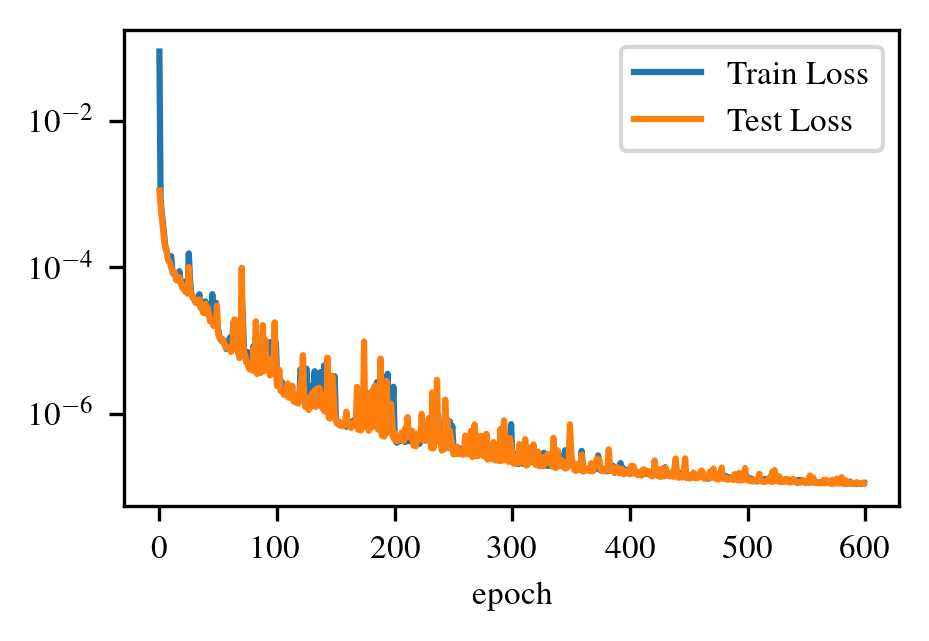

In [17]:
# Display Model Details
plt.figure(figsize=(1000 / 300, 618 / 300), dpi=300)
plt.rcParams['axes.unicode_minus'] = False  
plt.plot(train_lossArr, label="Train Loss",linewidth=1.5)
plt.plot(test_lossArr, label="Test Loss",linewidth=1.5)
plt.yscale("log")
plt.legend(fontsize="8")

testLoss = 0
trainLoss = 0
with torch.no_grad():
    for x, y in trainData:
        x, y = x.cuda(), y.cuda()
        out = modelk1((x, grid))
        out = out.reshape((out.shape[0], out.shape[1]))
        trainLoss +=  loss(out.view(batch_size, -1), y.view(batch_size, -1)).item() 
        
    for x, y in testData:
        x, y = x.cuda(), y.cuda()
        out = modelk1((x, grid))
        out = out.reshape((out.shape[0], out.shape[1]))
        testLoss +=   loss(out.view(batch_size, -1), y.view(batch_size, -1)).item() 
    
    
print("Avg Epoch Time:", sum(time_Arr)/len(time_Arr))
print("Final Testing Loss:", testLoss)
print("Final Training Loss:", trainLoss)
plt.tick_params(labelsize=8)
plt.xlabel(r"$\mathrm{epoch}$",fontsize = 8 )


In [18]:
# Verify NO-based kernel

c = 1

K1, K2, K3, N, gamma= kernel_estimator(Sigma11, Sigma12, Sigma21, Sigma22, Q, A, B, C, C_0, dx, Nx, Lambda, c)
c_matrix=buildc(Nx,c)
xdata = np.concatenate([c_matrix.reshape(1,-1)],axis=1)
xdata = np.array(xdata, dtype=np.float32)
xdata = torch.from_numpy(xdata.reshape((1, 1*Nx*Nx))).cuda() 
xdata1=xdata[:,0*Nx*Nx:1*Nx*Nx] 

# NO-based kernel
l_1= modelk1((xdata1, grid))
l_1 = l_1.detach().cpu().numpy().reshape(1, Nx*Nx)
l_1=l_1.reshape(Nx,Nx)

x = np.arange(0, L + dx, dx)
spatial = x

In [19]:
# Reduce dx interval

L2 = 1
dx2 = 0.05 


nx2 = round(L2 / dx2)
spatial2 = np.linspace(dx2, L2, nx2)

KuEst2 = np.zeros((20, 20))
KuEstNop2 = np.zeros((20, 20))
KuEst = K1
KuEstNop = l_1

for j in range(20): 
    for i in range(20):
        KuEst2[j,i]= KuEst[j*5,i*5]
        KuEstNop2[j,i] = KuEstNop[j*5,i*5]
Ku = np.array(KuEst2)

KuNop = np.array(KuEstNop2)

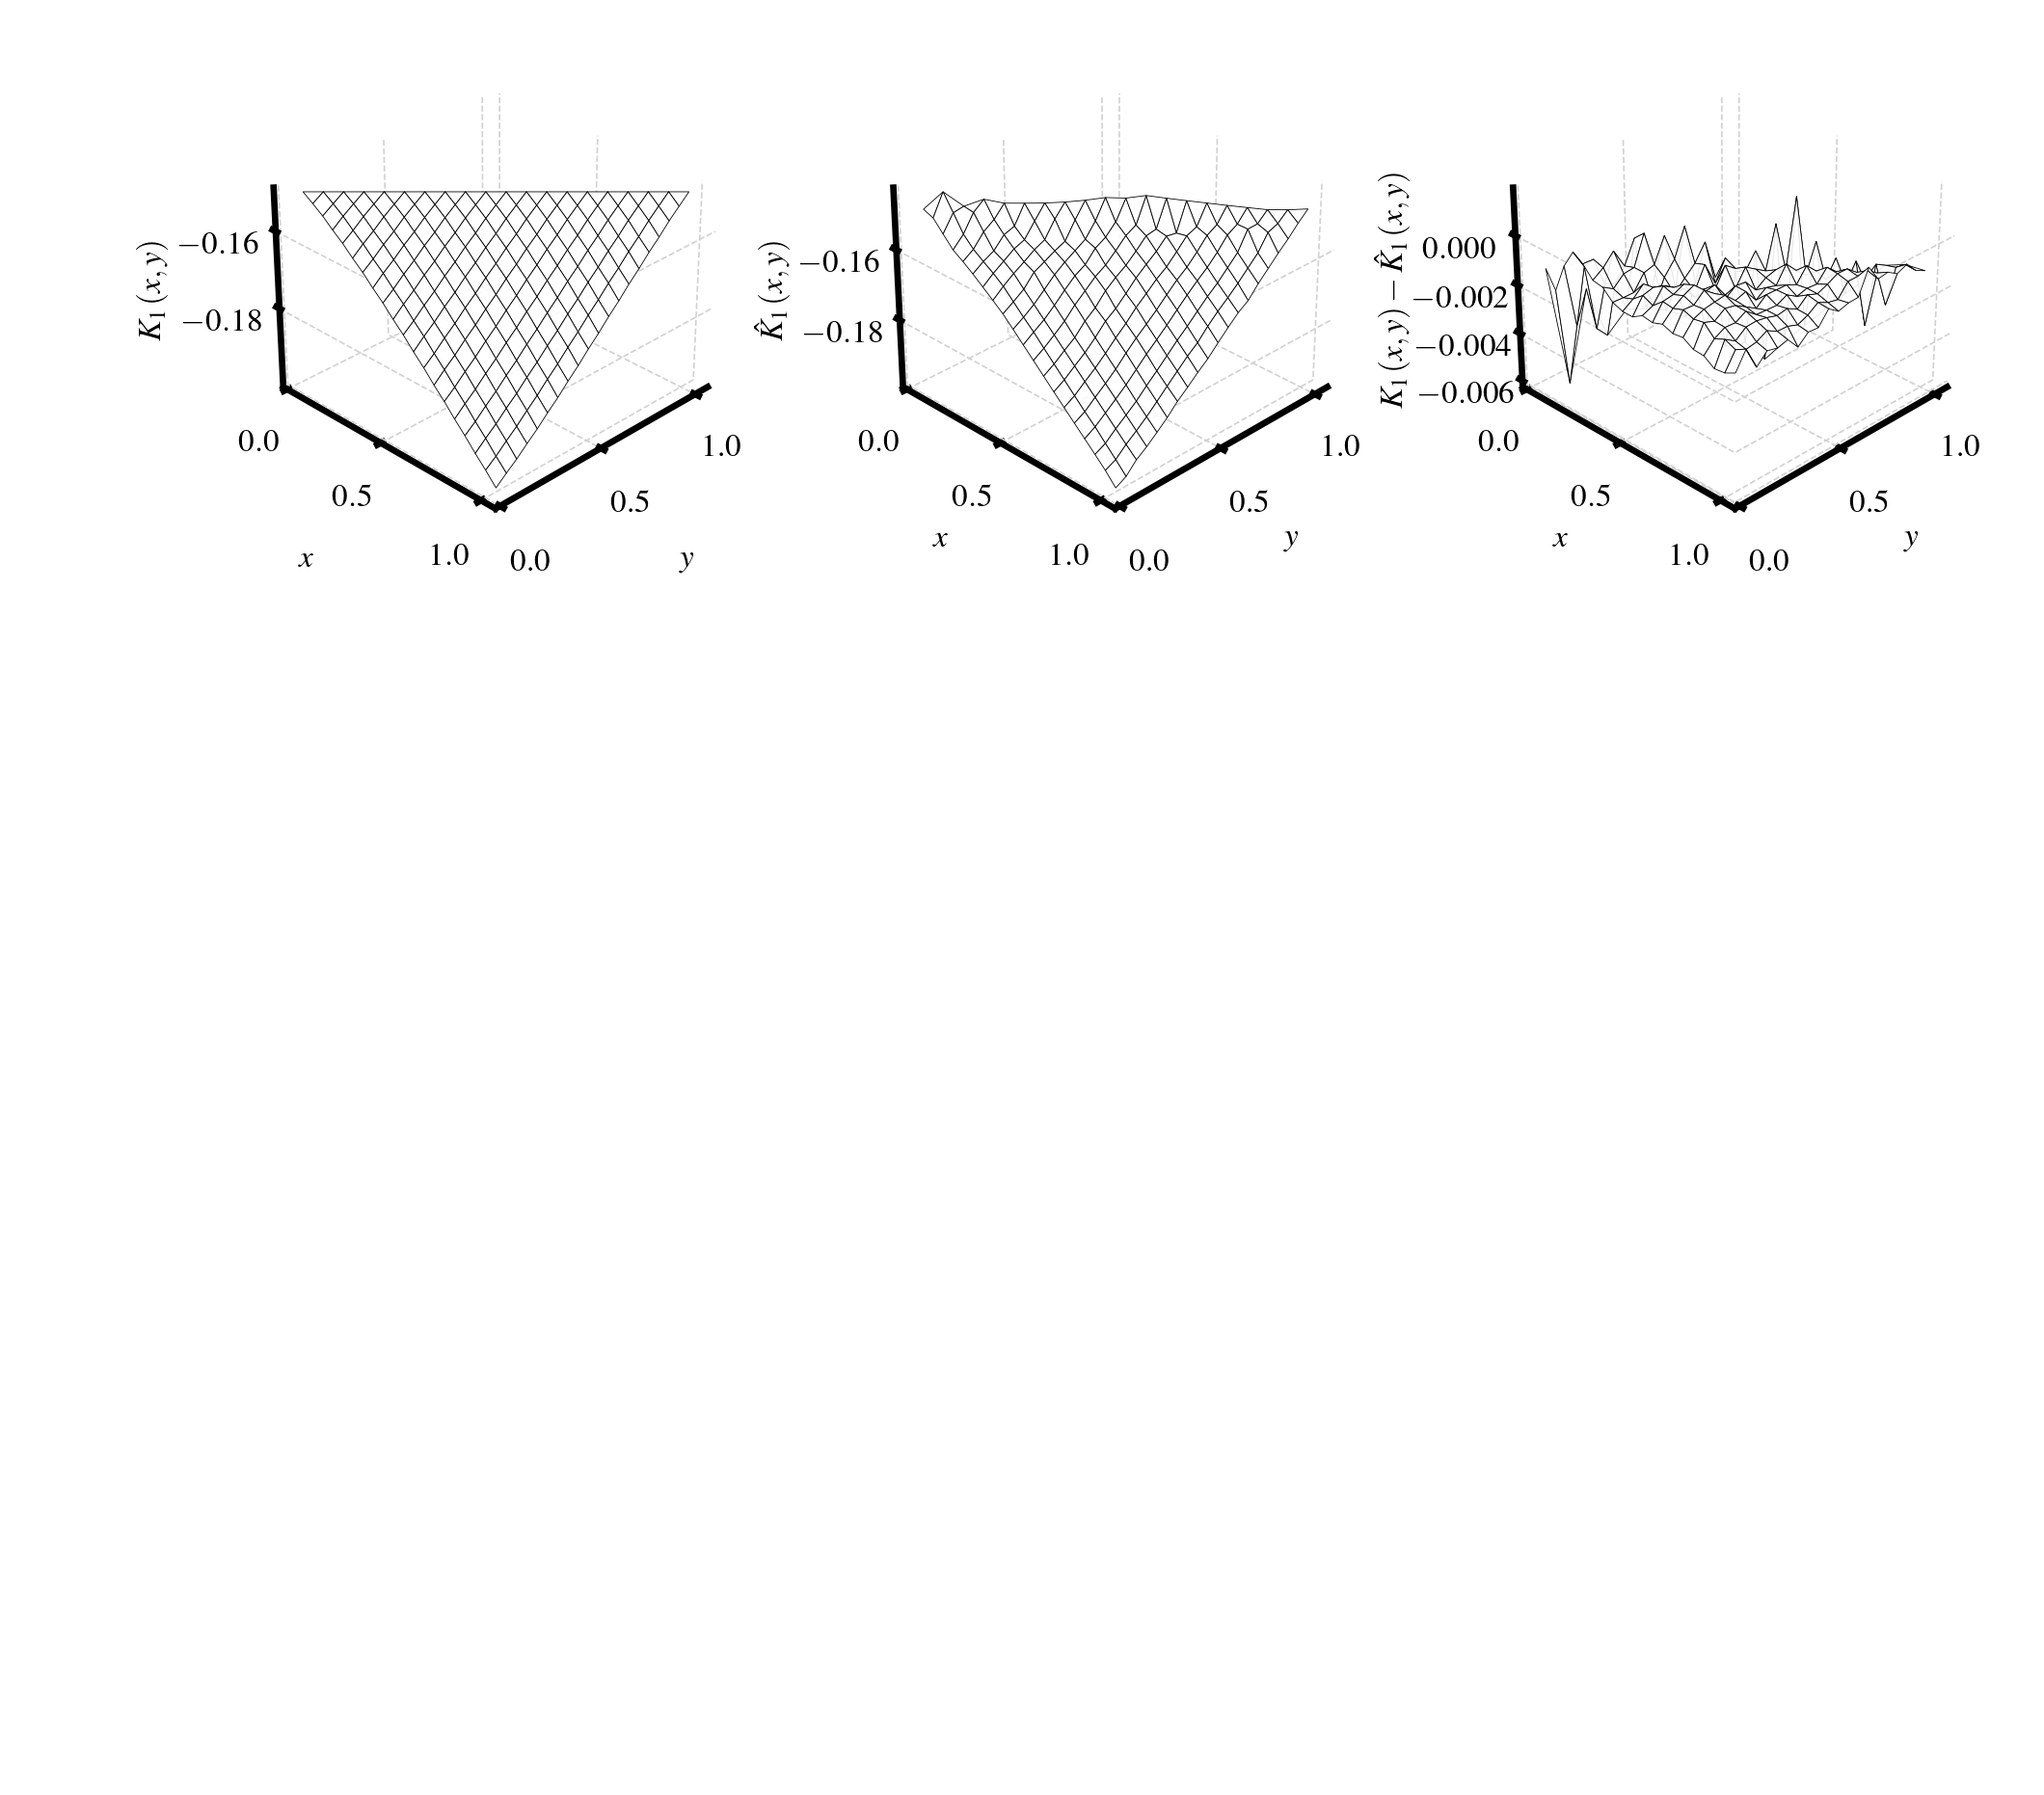

In [20]:
# draw kernel K1

my_dpi = 300
res = 10
meshy, meshx = np.meshgrid(spatial2, spatial2)


fig = plt.figure(figsize=(1000 / my_dpi, 1000 / my_dpi), dpi=600)
subfigs = fig.subfigures(nrows=2, ncols=1, hspace=0)

subfig = subfigs[0]
subfig.subplots_adjust(left=0.1, bottom=0, right=0.99, top=0.99, wspace=0.3, hspace=0)

ax = subfig.subplots(nrows=1, ncols=3, subplot_kw={"projection": "3d"})

for axis in [ax[0].xaxis, ax[0].yaxis, ax[0].zaxis]:
    axis._axinfo['axisline']['linewidth'] = 1
    axis._axinfo['axisline']['color'] = "b"
    axis._axinfo['grid']['linewidth'] = 0.2
    axis._axinfo['grid']['linestyle'] = "--"
    axis._axinfo['grid']['color'] = "#d1d1d1"
    axis.set_pane_color((1, 1, 1))
for axis in [ax[1].xaxis, ax[1].yaxis, ax[1].zaxis]:
    axis._axinfo['axisline']['linewidth'] = 1
    axis._axinfo['axisline']['color'] = "b"
    axis._axinfo['grid']['linewidth'] = 0.2
    axis._axinfo['grid']['linestyle'] = "--"
    axis._axinfo['grid']['color'] = "#d1d1d1"
    axis.set_pane_color((1, 1, 1))
for axis in [ax[2].xaxis, ax[2].yaxis, ax[2].zaxis]:
    axis._axinfo['axisline']['linewidth'] = 1
    axis._axinfo['axisline']['color'] = "b"
    axis._axinfo['grid']['linewidth'] = 0.2
    axis._axinfo['grid']['linestyle'] = "--"
    axis._axinfo['grid']['color'] = "#d1d1d1"
    axis.set_pane_color((1, 1, 1))
    
ax[0].plot_surface(meshx, meshy,zeroToNan(Ku),edgecolor="black",lw=0.1, 
                        color="white", shade=False, rasterized=True,alpha=0.9,antialiased=True, rstride=1, cstride=1)   
zticks = np.linspace(-15, 12, 6)
ax[0].view_init(30,-45)
ax[0].set_xlabel(r"$x$",fontsize = 4 , labelpad=-10)
ax[0].set_ylabel(r"$y$",fontsize = 4 , labelpad=-10)
ax[0].set_zlabel(r"${K}_1(x, y)$", fontsize = 4 , rotation = 90, labelpad=-12)

ax[0].set_xticks([0, 0.5, 1])
ax[0].set_yticks([0, 0.5, 1])
ax[0].zaxis.set_rotate_label(False)
ax[0].yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
ax[0].tick_params(axis='both',  
                      labelsize=4 , pad=-4)  
tmp_planes = ax[0].zaxis._PLANES 
ax[0].zaxis._PLANES = ( tmp_planes[2], tmp_planes[3], 
                     tmp_planes[0], tmp_planes[1], 
                     tmp_planes[4], tmp_planes[5])
ax[1].plot_surface(meshx, meshy, zeroToNan(KuNop),edgecolor="black",lw=0.1, 
                        color="white", shade=False, rasterized=True,alpha=0.9,antialiased=True, rstride=1, cstride=1)

ax[1].view_init(30, -45)
ax[1].set_xlabel(r"$x$",fontsize = 4 , labelpad=-12)
ax[1].set_ylabel(r"$y$",fontsize = 4 , labelpad=-12)
ax[1].set_zlabel(r"$\hat{K}_1(x, y)$", fontsize = 4 ,rotation = 90, labelpad=-12)
ax[1].zaxis.set_rotate_label(False)
ax[1].set_xticks([0, 0.5, 1])
ax[1].set_yticks([0, 0.5, 1])
ax[1].yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
ax[1].tick_params(axis='both',  
                      labelsize=4, pad=-4 ) 


ax[2].plot_surface(meshx, meshy, zeroToNan(Ku-KuNop),edgecolor="black",lw=0.1, 
                        color="white", shade=False, rasterized=True,alpha=0.9,antialiased=True, rstride=1, cstride=1)   
test = np.zeros(int(301))
zticks = np.linspace(-15, 12, 6)
ax[2].view_init(30,-45)
ax[2].set_xlabel(r"$x$",fontsize = 4 , labelpad=-12)
ax[2].set_ylabel(r"$y$",fontsize = 4 , labelpad=-12)
ax[2].set_zlabel(r"${K}_1(x,y)-\hat{K}_1(x,y)$",fontsize = 4 , rotation = 90, labelpad=-12)
ax[2].set_xticks([0, 0.5, 1])
ax[2].set_yticks([0, 0.5, 1])
ax[2].zaxis.set_rotate_label(False)
ax[2].yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
ax[2].tick_params(axis='both',  
                      labelsize=4, pad=-4 )  

tmp_planes = ax[1].zaxis._PLANES 
ax[1].zaxis._PLANES = ( tmp_planes[2], tmp_planes[3], 
                     tmp_planes[0], tmp_planes[1], 
                     tmp_planes[4], tmp_planes[5]) 

tmp_planes = ax[2].zaxis._PLANES 
ax[2].zaxis._PLANES = ( tmp_planes[2], tmp_planes[3], 
                     tmp_planes[0], tmp_planes[1], 
                     tmp_planes[4], tmp_planes[5]) 
plt.savefig("img/K1.png", dpi=300)

In [21]:
pathL='./Model/cc1c2ToCtrlTorchModeK1.pth' 
torch.save(modelk1.state_dict(), pathL)  

In [22]:
modelk11.load_state_dict(torch.load(pathL))  #test

<All keys matched successfully>

In [23]:
# Verify that the closed-loop system is stable

L2 = 1
dx2 = 0.05 # 0.01
nx2 = round(L2 / dx2)
spatial2 = np.linspace(dx2, L2, nx2)

L = 1
T = 70
dx = 0.01
dt = 0.005
dy = dx

x = np.arange(0, L + dx, dx)
y = np.arange(0, L + dy, dy)
t = np.arange(0, T + dt, dt)
temporal = t

Nx = len(x)
Nt = len(t)
step = 1


Lambda = np.diag([1, 1, 1])  # Lambda+
mu = 1  # Lambda-

Sigma11 = np.diag([0.3, 0.3, 0.3])  # Sigma++
Sigma12 = np.array([[0.5], [-0.1], [0.2]])  # Sigma+-
Sigma21 = np.array([[0.3, -0.2, 0.1]])  # Sigma-+
Sigma22 = 0.3  # Sigma--

Q = np.array([[1], [1], [1]])
R = np.array([[1, 1, 1]])

A = np.array([[0, 2], [-2, 0]])
B = np.array([[2], [1]])
K = np.array([[-2, -1]])

C = np.array([[1, 0], [0, 0], [0, 0]])
C_0 = C + Q @ K


init_cond_w1 = np.cos(2 * np.pi * x) 
init_cond_w2 = np.cos(2 * np.pi * x) 
init_cond_w3 = np.cos(2 * np.pi * x) 
init_cond_z = x.copy()
init_cond_X = np.array([[1], [-1]])

In [24]:
# Compute the state of closed-loop systems and neural operator-based states

w1, w2, w3, z, X, U, prob_matrix, K1_r, K2_r, K3_r, N_r, gamma_r, mu_values, x, t = solve_pde(params)
w1Nop, w2Nop, w3Nop, zNop, XNop, UNop, prob_matrixNop, K1_rNop, K2_rNop, K3_rNop, N_rNop, gamma_rNop, mu_valuesNop, x, t = solve_pde_NO(params,l_1)


In [25]:
#验证闭环系统

w1 = np.transpose(np.array(w1))
w2 = np.transpose(np.array(w2))
w3 = np.transpose(np.array(w3))
z = np.transpose(np.array(z))

w1Nop = np.transpose(np.array(w1Nop))
w2Nop = np.transpose(np.array(w2Nop))
w3Nop = np.transpose(np.array(w3Nop))
zNop = np.transpose(np.array(zNop))

error_w1=w1-w1Nop
error_w2=w2-w2Nop
error_w3=w3-w3Nop
error_z=z-zNop
error_X=X-XNop


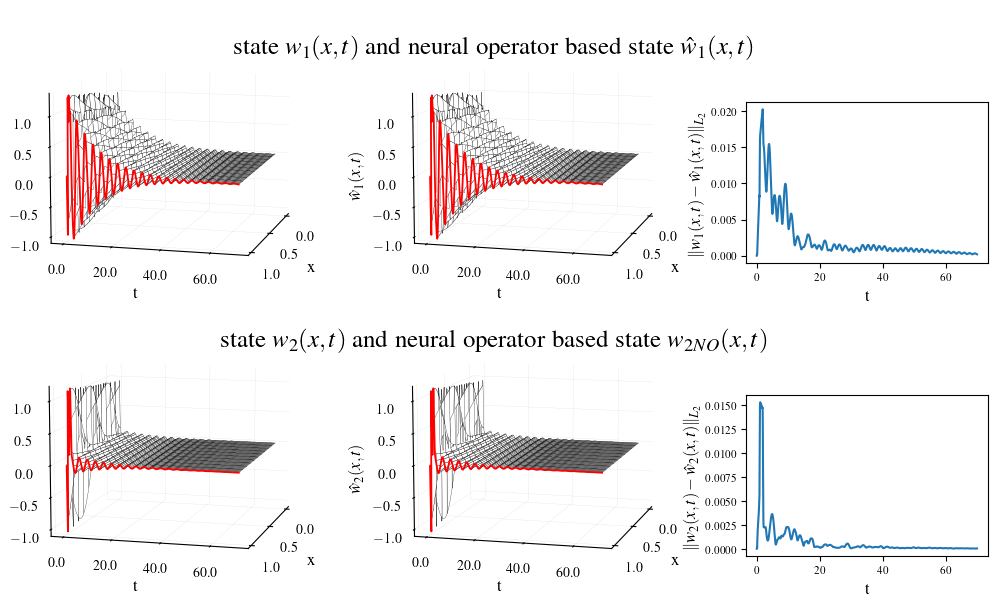

In [26]:
# Draw 
# w1 w2, w1Nop, w2Nop and errors

u=w1
v=w2
uNop=w1Nop
vNop=w2Nop
temporal = t
nt=Nt

res = 1
fig = plt.figure(figsize=set_size(1000, 0.8, (2,3), height_add=1.3)) 
subfigs = fig.subfigures(nrows=2, ncols=1, hspace=0)


# Row 1
#（1，1）
subfig = subfigs[0]
subfig.subplots_adjust(left=0.07, bottom=0, right=1, top=1.1)
subfig.suptitle(r"state $w_1(x, t)$ and neural operator based state $\hat{w}_{1}(x, t)$", fontsize=18)
axes = subfig.subplots(nrows=1, ncols=3, subplot_kw={"projection": "3d", "computed_zorder": False}) 

for ax in axes:
    for axis in [ax.xaxis, ax.yaxis, ax.zaxis]:
        axis._axinfo['axisline']['linewidth'] = 1
        axis._axinfo['axisline']['color'] = "b"
        axis._axinfo['grid']['linewidth'] = 0.2
        axis._axinfo['grid']['linestyle'] = "--"
        axis._axinfo['grid']['color'] = "#d1d1d1"
        axis.set_pane_color((1,1,1))
    
meshx, mesht = np.meshgrid(spatial, temporal)
                     
axes[0].plot_surface(meshx, mesht, u, edgecolor="black",lw=0.2, rstride=70, cstride=10, 
                        alpha=1, color="white", shade=False, rasterized=True, antialiased=True)
test = np.ones(nt)
vals = (uNop.transpose())[-1] 
axes[0].plot(test[1:], temporal[1:], vals[1:], color="red", lw=1.3, antialiased=True)
axes[0].view_init(10, 15)
axes[0].set_xlabel("x")
axes[0].set_ylabel("t")
axes[0].set_zlabel(r"$w_1(x, t)$", rotation=90)
axes[0].zaxis.set_rotate_label(False)
axes[0].set_xticks([0, 0.5, 1])
axes[0].yaxis.set_major_formatter(FormatStrFormatter('%.1f'))

#（1，2）
axes[1].plot_surface(meshx, mesht, uNop, edgecolor="black",lw=0.2, rstride=70, cstride=10, 
                        alpha=1, color="white", shade=False, rasterized=True, antialiased=True)
test = np.ones(nt)
vals = (uNop.transpose())[-1] 
axes[1].plot(test[1:], temporal[1:], vals[1:], color="red", lw=1.3, antialiased=True)
axes[1].view_init(10, 15)
axes[1].set_xlabel("x")
axes[1].set_ylabel("t")
axes[1].set_zlabel(r"$\hat{w}_{1}(x,t)$", rotation=90)
axes[1].zaxis.set_rotate_label(False)
axes[1].set_xticks([0, 0.5, 1])
axes[1].yaxis.set_major_formatter(FormatStrFormatter('%.1f'))

#（1，3）
axes[2].remove()  
ax2d = subfig.add_subplot(1, 3, 3)  


# error
ee_state=u-uNop
error_u_state_L2=np.sqrt(np.sum(ee_state*ee_state,axis=1)*dx)
nt_draw=nt 
plt.rcParams['axes.unicode_minus'] = False  
plt.rcParams['axes.unicode_minus'] = False  


pos3 = ax2d.get_position()  
new_pos3 = [pos3.x0, pos3.y0 + 0.2, pos3.width * 0.8, pos3.height * 0.5]  
ax2d.set_position(new_pos3)  


ax2d.plot(temporal[0:nt_draw], error_u_state_L2[0:nt_draw],linewidth=1.5)
ax2d.set_xlabel(r'$\rm{t}$',fontsize="12")
ax2d.set_ylabel(r'$\Vert w_1(x,t) -  \hat{w}_{1}(x,t)\Vert_{L_2}$',fontsize="12")
plt.tick_params(labelsize=8)

# Row 2
subfig = subfigs[1]
subfig.subplots_adjust(left=0.07, bottom=0, right=1, top=1.1)
subfig.suptitle(r"state $w_2(x, t)$ and neural operator based state ${w}_{2NO}(x, t)$", fontsize=18)
axes = subfig.subplots(nrows=1, ncols=3, subplot_kw={"projection": "3d", "computed_zorder": False})

for ax in axes:
    for axis in [ax.xaxis, ax.yaxis, ax.zaxis]:
        axis._axinfo['axisline']['linewidth'] = 1
        axis._axinfo['axisline']['color'] = "b"
        axis._axinfo['grid']['linewidth'] = 0.2
        axis._axinfo['grid']['linestyle'] = "--"
        axis._axinfo['grid']['color'] = "#d1d1d1"
        axis.set_pane_color((1,1,1))
    
meshx, mesht = np.meshgrid(spatial, temporal)
#（2，1）
    
axes[0].plot_surface(meshx, mesht, v, edgecolor="black",lw=0.2, rstride=70, cstride=10, 
                        alpha=1, color="white", shade=False, rasterized=True, antialiased=True)
test = np.ones(nt)
vals = (v.transpose())[-1] 
axes[0].plot(test[1:], temporal[1:], vals[1:], color="red", lw=1.3, antialiased=True)
axes[0].view_init(10, 15)
axes[0].set_xlabel("x")
axes[0].set_ylabel("t")
axes[0].set_zlabel(r"$w_2(x,t)$", rotation=90)
axes[0].zaxis.set_rotate_label(False)
axes[0].set_xticks([0, 0.5, 1])
axes[0].yaxis.set_major_formatter(FormatStrFormatter('%.1f'))

#（2，2）
axes[1].plot_surface(meshx, mesht, vNop, edgecolor="black",lw=0.2, rstride=70, cstride=10, 
                        alpha=1, color="white", shade=False, rasterized=True, antialiased=True)
test = np.ones(nt)
vals = (vNop.transpose())[-1] 
axes[1].plot(test[1:], temporal[1:], vals[1:], color="red", lw=1.3, antialiased=True)
axes[1].view_init(10, 15)
axes[1].set_xlabel("x")
axes[1].set_ylabel("t")
axes[1].set_zlabel(r"$\hat{w}_{2}(x,t)$", rotation=90)
axes[1].zaxis.set_rotate_label(False)
axes[1].set_xticks([0, 0.5, 1])
axes[1].yaxis.set_major_formatter(FormatStrFormatter('%.1f'))

#（2，3）位置的图
axes[2].remove()  
ax2d = subfig.add_subplot(1, 3, 3)  

ee_state2=v-vNop
error_v_state_L2=np.sqrt(np.sum(ee_state2*ee_state2,axis=1)*dx)
nt_draw=nt 

plt.rcParams['axes.unicode_minus'] = False  
plt.rcParams['axes.unicode_minus'] = False  

pos3 = ax2d.get_position()  
new_pos3 = [pos3.x0, pos3.y0 + 0.2, pos3.width * 0.8, pos3.height * 0.5]  
ax2d.set_position(new_pos3)  

ax2d.plot(temporal[0:nt_draw], error_v_state_L2[0:nt_draw],linewidth=1.5)
ax2d.set_xlabel(r'$\rm{t}$',fontsize="12")
ax2d.set_ylabel(r'$\Vert w_2(x,t) -  \hat{w}_{2}(x,t)\Vert_{L_2}$',fontsize="12")
plt.tick_params(labelsize=8)

plt.savefig("img/State_w1w2_w1NOw2NO.png", dpi=600)

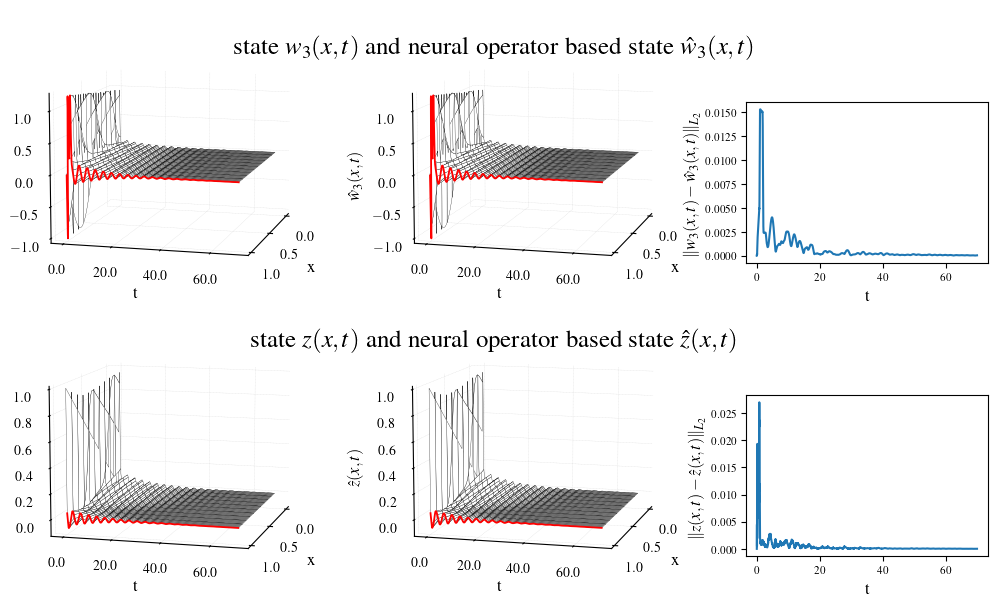

In [27]:
# Draw 
# w3 z, w3Nop, zNop and errors

u=w3
v=z
uNop=w3Nop
vNop=zNop
temporal = t
nt=Nt

res = 1
fig = plt.figure(figsize=set_size(1000, 0.8, (2,3), height_add=1.3)) 
subfigs = fig.subfigures(nrows=2, ncols=1, hspace=0)


#Row 1
#（1，1）
subfig = subfigs[0]
subfig.subplots_adjust(left=0.07, bottom=0, right=1, top=1.1)
subfig.suptitle(r"state $w_3(x, t)$ and neural operator based state $\hat{w}_{3}(x, t)$", fontsize=18)
axes = subfig.subplots(nrows=1, ncols=3, subplot_kw={"projection": "3d", "computed_zorder": False})



for ax in axes:
    for axis in [ax.xaxis, ax.yaxis, ax.zaxis]:
        axis._axinfo['axisline']['linewidth'] = 1
        axis._axinfo['axisline']['color'] = "b"
        axis._axinfo['grid']['linewidth'] = 0.2
        axis._axinfo['grid']['linestyle'] = "--"
        axis._axinfo['grid']['color'] = "#d1d1d1"
        axis.set_pane_color((1,1,1))
    
meshx, mesht = np.meshgrid(spatial, temporal)
                     
axes[0].plot_surface(meshx, mesht, u, edgecolor="black",lw=0.2, rstride=70, cstride=10, 
                        alpha=1, color="white", shade=False, rasterized=True, antialiased=True)
test = np.ones(nt)
vals = (uNop.transpose())[-1] 
axes[0].plot(test[1:], temporal[1:], vals[1:], color="red", lw=1.3, antialiased=True)
axes[0].view_init(10, 15)
axes[0].set_xlabel("x")
axes[0].set_ylabel("t")
axes[0].set_zlabel(r"$w_3(x, t)$", rotation=90)
axes[0].zaxis.set_rotate_label(False)
axes[0].set_xticks([0, 0.5, 1])
axes[0].yaxis.set_major_formatter(FormatStrFormatter('%.1f'))

#（1，2）
axes[1].plot_surface(meshx, mesht, uNop, edgecolor="black",lw=0.2, rstride=70, cstride=10, 
                        alpha=1, color="white", shade=False, rasterized=True, antialiased=True)
test = np.ones(nt)
vals = (uNop.transpose())[-1] 
axes[1].plot(test[1:], temporal[1:], vals[1:], color="red", lw=1.3, antialiased=True)
axes[1].view_init(10, 15)
axes[1].set_xlabel("x") 
axes[1].set_ylabel("t")
axes[1].set_zlabel(r"$\hat{w}_{3}(x,t)$", rotation=90)
axes[1].zaxis.set_rotate_label(False)
axes[1].set_xticks([0, 0.5, 1])
axes[1].yaxis.set_major_formatter(FormatStrFormatter('%.1f'))

#（1，3）
axes[2].remove()  
ax2d = subfig.add_subplot(1, 3, 3)  


ee_state=u-uNop
error_u_state_L2=np.sqrt(np.sum(ee_state*ee_state,axis=1)*dx)
nt_draw=nt 

plt.rcParams['axes.unicode_minus'] = False  
plt.rcParams['axes.unicode_minus'] = False  

pos3 = ax2d.get_position()  
new_pos3 = [pos3.x0, pos3.y0 + 0.2, pos3.width * 0.8, pos3.height * 0.5]  
ax2d.set_position(new_pos3) 


ax2d.plot(temporal[0:nt_draw], error_u_state_L2[0:nt_draw],linewidth=1.5)
ax2d.set_xlabel(r'$\rm{t}$',fontsize="12")
ax2d.set_ylabel(r'$\Vert w_3(x,t) -  \hat{w}_{3}(x,t)\Vert_{L_2}$',fontsize="12")
plt.tick_params(labelsize=8)

# Row 2

subfig = subfigs[1]
subfig.subplots_adjust(left=0.07, bottom=0, right=1, top=1.1)
subfig.suptitle(r"state $z(x, t)$ and neural operator based state $\hat{z}(x, t)$", fontsize=18)
axes = subfig.subplots(nrows=1, ncols=3, subplot_kw={"projection": "3d", "computed_zorder": False})

for ax in axes:
    for axis in [ax.xaxis, ax.yaxis, ax.zaxis]:
        axis._axinfo['axisline']['linewidth'] = 1
        axis._axinfo['axisline']['color'] = "b"
        axis._axinfo['grid']['linewidth'] = 0.2
        axis._axinfo['grid']['linestyle'] = "--"
        axis._axinfo['grid']['color'] = "#d1d1d1"
        axis.set_pane_color((1,1,1))
    
meshx, mesht = np.meshgrid(spatial, temporal)

#（2，1）                  
axes[0].plot_surface(meshx, mesht, v, edgecolor="black",lw=0.2, rstride=70, cstride=10, 
                        alpha=1, color="white", shade=False, rasterized=True, antialiased=True)
test = np.ones(nt)
vals = (v.transpose())[-1] 
axes[0].plot(test[1:], temporal[1:], vals[1:], color="red", lw=1.3, antialiased=True)
axes[0].view_init(10, 15)
axes[0].set_xlabel("x")
axes[0].set_ylabel("t")
axes[0].set_zlabel(r"$z(x,t)$", rotation=90)
axes[0].zaxis.set_rotate_label(False)
axes[0].set_xticks([0, 0.5, 1])
axes[0].yaxis.set_major_formatter(FormatStrFormatter('%.1f'))

#（2，2）
axes[1].plot_surface(meshx, mesht, vNop, edgecolor="black",lw=0.2, rstride=70, cstride=10, 
                        alpha=1, color="white", shade=False, rasterized=True, antialiased=True)
test = np.ones(nt)
vals = (vNop.transpose())[-1] 
axes[1].plot(test[1:], temporal[1:], vals[1:], color="red", lw=1.3, antialiased=True)
axes[1].view_init(10, 15)
axes[1].set_xlabel("x")
axes[1].set_ylabel("t")
axes[1].set_zlabel(r"$\hat{z}(x,t)$", rotation=90)
axes[1].zaxis.set_rotate_label(False)
axes[1].set_xticks([0, 0.5, 1])
axes[1].yaxis.set_major_formatter(FormatStrFormatter('%.1f'))

#（2，3）
axes[2].remove() 
ax2d = subfig.add_subplot(1, 3, 3)  


ee_state2=v-vNop
error_v_state_L2=np.sqrt(np.sum(ee_state2*ee_state2,axis=1)*dx)
nt_draw=nt 

plt.rcParams['axes.unicode_minus'] = False  
plt.rcParams['axes.unicode_minus'] = False  



pos3 = ax2d.get_position()  
new_pos3 = [pos3.x0, pos3.y0 + 0.2, pos3.width * 0.8, pos3.height * 0.5]  
ax2d.set_position(new_pos3)  
ax2d.plot(temporal[0:nt_draw], error_v_state_L2[0:nt_draw],linewidth=1.5)
ax2d.set_xlabel(r'$\rm{t}$',fontsize="12")
ax2d.set_ylabel(r'$\Vert z(x,t) -  \hat{z}(x,t)\Vert_{L_2}$',fontsize="12")
plt.tick_params(labelsize=8)

plt.savefig("img/State_w3z_w3NOzNO.png", dpi=600)

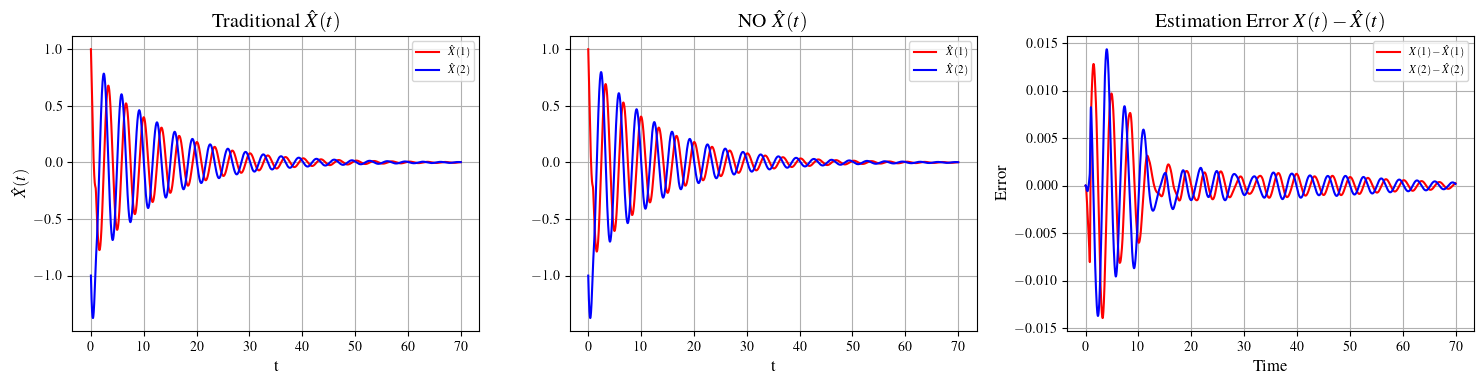

In [28]:
# Draw state X 
dt = 0.005  
Nt = X.shape[1]
t = np.linspace(0, dt * (Nt - 1), Nt)
error = X - XNop
fig, axs = plt.subplots(1, 3, figsize=(15, 4))
axs[0].plot(t, X[0], 'r', label=r'$\hat{X}(1)$')
axs[0].plot(t, X[1], 'b', label=r'$\hat{X}(2)$')
axs[0].set_title(r'Traditional $\hat{X}(t)$')
axs[0].set_xlabel('t')
axs[0].set_ylabel(r'$\hat{X}(t)$')
axs[0].legend()
axs[0].grid(True)

axs[1].plot(t, XNop[0], 'r', label=r'$\hat{X}(1)$')
axs[1].plot(t, XNop[1], 'b', label=r'$\hat{X}(2)$')
axs[1].set_title(r'NO $\hat{X}(t)$')
axs[1].set_xlabel('t')
axs[1].legend()
axs[1].grid(True)

axs[2].plot(t, error[0], 'r', label=r'$X(1)-\hat{X}(1)$')
axs[2].plot(t, error[1], 'b', label=r'$X(2)-\hat{X}(2)$')
axs[2].set_title(r'Estimation Error $X(t) - \hat{X}(t)$')
axs[2].set_xlabel('Time')
axs[2].set_ylabel('Error')
axs[2].legend()
axs[2].grid(True)

plt.tight_layout()
plt.show()

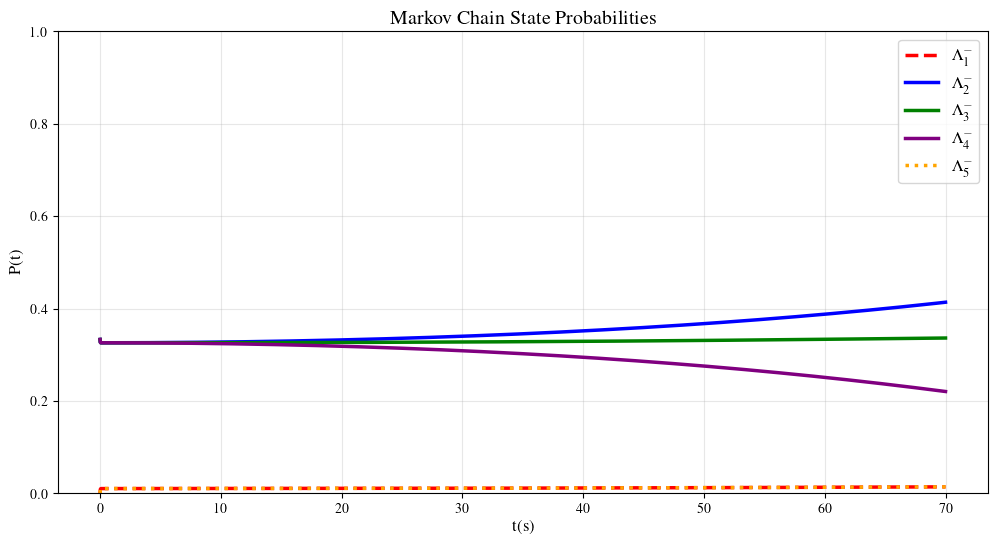

In [29]:
# Draw Markov Chain State Probabilities
plt.figure(figsize=(12, 6))
colors = ['red', 'blue', 'green', 'purple', 'orange']
line_styles = ['-', '-', '-', '-', ':']

for i in range(5):
    if i == 0:
        plt.plot(t, prob_matrix[:, i], color='red', linestyle='--', 
                linewidth=2.5, label=f'$\\Lambda^-_1$ ')
    elif i == 4:
        plt.plot(t, prob_matrix[:, i], color='orange', linestyle=':', 
                linewidth=2.5, label=f'$\\Lambda^-_5$ ')
    else:
        plt.plot(t, prob_matrix[:, i], color=colors[i], linestyle=line_styles[i], 
                linewidth=2.5, label=f'$\\Lambda^-_{i+1}$')

plt.xlabel('t(s)', fontsize=12)
plt.ylabel('P(t)', fontsize=12)
plt.ylim([0, 1])
plt.legend(fontsize=12, loc='upper right')
plt.grid(True, alpha=0.3)
plt.title('Markov Chain State Probabilities')

# Save the figure
plt.show()

In [30]:
# Computation time comparison
# Parameter Definition
L2 = 1
dx2 = 0.05 # 0.01
nx2 = round(L2 / dx2)
spatial2 = np.linspace(dx2, L2, nx2)

L = 1
T = 70
dx = 0.01
dt = 0.005
dy = dx

x = np.arange(0, L + dx, dx)
y = np.arange(0, L + dy, dy)
t = np.arange(0, T + dt, dt)
temporal = t

Nx = len(x)
Nt = len(t)
step = 1

Lambda = np.diag([1, 1, 1])  # Lambda+
mu = 1  # Lambda-

Sigma11 = np.diag([0.3, 0.3, 0.3])  # Sigma++
Sigma12 = np.array([[0.5], [-0.1], [0.2]])  # Sigma+-
Sigma21 = np.array([[0.3, -0.2, 0.1]])  # Sigma-+
Sigma22 = 0.3  # Sigma--

Q = np.array([[1], [1], [1]])
R = np.array([[1, 1, 1]])

A = np.array([[0, 2], [-2, 0]])
B = np.array([[2], [1]])
K = np.array([[-2, -1]])

C = np.array([[1, 0], [0, 0], [0, 0]])
C_0 = C + Q @ K

init_cond_w1 = np.cos(2 * np.pi * x) 
init_cond_w2 = np.cos(2 * np.pi * x) 
init_cond_w3 = np.cos(2 * np.pi * x) 
init_cond_z = x.copy()
init_cond_X = np.array([[1], [-1]])



# NO's computatinal time
timeSum2 = 0
with torch.no_grad():
    for x, y in testData:
        x, y = x.cuda(), y.cuda()
        s = time.time() 
        out = modelk1((x, grid))
        timeSum2 += time.time()-s
time2 = timeSum2/(ndata*0.1)
print(time2)

# Tranditinal method's computatinal time
timeSum = 0
for i in range(100):
    s = time.time()
    K1, K2, K3, N, gamma= kernel_estimator(Sigma11, Sigma12, Sigma21.T, Sigma22, Q, A, B, C, C_0, dx, Nx, Lambda, 1)
    timeSum += time.time()-s
time1 = timeSum/100
print(time1)

print(time1/time2)

3.998756408691406e-05
0.053550395965576175
1339.1762461244932
